# Meta-Analysis Fundamentals: Combining a Pile of Studies into a Defensible Estimate

A single question asked many times, answers scattered across dozens of papers: does BCG really prevent tuberculosis? How large is the effect of a psychological intervention? Each study gives one number, but they don't fully agree — some say effective, others say no difference; sample sizes range from dozens to tens of thousands. **Meta-analysis** is the process of combining these studies' effect sizes by precision weighting into a single pooled estimate and **honestly reporting its uncertainty**. It is not simply averaging: larger studies should have more voice, and true differences between studies (heterogeneity) must be quantified rather than erased.

This notebook uses **real, classic** data—13 BCG trials testing tuberculosis prevention (Colditz et al. 1994, also the most commonly used teaching dataset `dat.bcg` in R's `metafor` package)—to walk through a standard meta-analysis:

1. **Effect sizes**: compute each trial's 2×2 table into log risk ratio + sampling variance;
2. **Fixed effects vs. random effects**: two pooling assumptions, and why random effects is almost always more honest;
3. **Heterogeneity**: Cochran's Q, I², τ² — how much do studies differ, is it real?
4. **Knapp-Hartung**: more robust confidence intervals in small samples;
5. **Prediction intervals**: where the true effect of a future study probably falls — conveys the consequences of "heterogeneity" better than the pooled point estimate;
6. **Publication bias**: Egger test + funnel plot;
7. **Forest plot**: draw all evidence into one figure.

The key advantage: `socialverse`'s pooled results match `metafor` **bit-for-bit** (random-effects log-RR = −0.7145, τ² = 0.313, I² = 92%) — the same statistics, pure numpy/scipy implementation, no R dependency.

> **Comparison**: R `metafor::rma` / `meta::metabin` · Stata `meta`.

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. Data: 13 BCG Trials

Each trial is a 2×2 table: among vaccinated, how many got TB (`tpos`), how many did not (`tneg`); same for controls (`cpos` / `cneg`). There is also a moderator we will use later — the trial location's **absolute latitude** `ablat` (higher latitude, colder regions, BCG appears more effective, which is the most famous finding from this dataset).

In [2]:
bcg = ds.load_bcg()
bcg

,trial,author,year,tpos,tneg,cpos,cneg,ablat
0,Trial 1,Aronson,1948,4,119,11,128,44
1,Trial 2,Ferguson & Simes,1949,6,300,29,274,55
2,Trial 3,Rosenthal et al,1960,3,228,11,209,42
3,Trial 4,Hart & Sutherland,1977,62,13536,248,12619,52
4,Trial 5,Frimodt-Moller et al,1973,33,5036,47,5761,13
5,Trial 6,Stein & Aronson,1953,180,1361,372,1079,44
6,Trial 7,Vandiviere et al,1973,8,2537,10,619,19
7,Trial 8,TPT Madras,1980,505,87886,499,87892,13
8,Trial 9,Coetzee & Berjak,1968,29,7470,45,7232,27
9,Trial 10,Rosenthal et al,1961,17,1699,65,1600,42


## 2. Effect Sizes: Log Risk Ratio

Directly comparing the 'disease incidence' across studies makes no sense (different sample sizes). First compress each trial into a single **comparable effect size** + its **sampling variance**. For binary outcomes, the standard choice is **risk ratio (RR)**: risk of disease in the vaccinated group ÷ risk in the control group. RR < 1 indicates protection. To make it symmetric and variance tractable, we use its logarithm `log(RR)` for pooling.

`socialverse` organizes an analysis around a `StudyState` object: data goes in, each `sv.*` function declares "what it needs, what it produces," and we follow the contract. `sv.pp.escalc` is the entry point for effect size calculation, routing by `measure=` — here we choose `"RR"`, and conveniently store `trial` as study labels and bring `ablat`/`year` as moderators.

In [3]:
study = sv.StudyState()
study.write("sources", "datasets", bcg)

sv.pp.escalc(study, measure="RR",
             ai="tpos", bi="tneg", ci="cpos", di="cneg",
             study="trial", slab="trial", moderators=["ablat", "year"])

eff = study.models["meta_effects"]
eff[["slab", "yi", "vi", "sei"]].round(4)

,slab,yi,vi,sei
0,Trial 1,-0.8893,0.3256,0.5706
1,Trial 2,-1.5854,0.1946,0.4411
2,Trial 3,-1.3481,0.4154,0.6445
3,Trial 4,-1.4416,0.0200,0.1415
4,Trial 5,-0.2175,0.0512,0.2263
5,Trial 6,-0.7861,0.0069,0.0831
6,Trial 7,-1.6209,0.2230,0.4722
7,Trial 8,0.0120,0.0040,0.0629
8,Trial 9,-0.4694,0.0564,0.2376
9,Trial 10,-1.3713,0.0730,0.2702


Each row now has `yi` (log-RR) and `vi` (sampling variance). Most `yi` values are negative — the general direction is protective. But differences between studies are substantial (from nearly ineffective to strong protection), which is exactly the **heterogeneity** we quantify next.

## 3. Fixed Effects vs. Random Effects

There are two pooling assumptions:

- **Fixed-effect (or common-effect)**: assumes all studies estimate **the same** true value, and differences arise purely from sampling error. Pool by inverse-variance weighting `1/vi`. This assumption almost certainly does not hold here — trials from different eras, different latitudes, and different populations should have different true effects.
- **Random-effects**: assumes each study's true effect is drawn from a distribution centered on an overall mean, with variance `τ²`. Weights become `1/(vi + τ²)` — the greater the between-study variance, the more the relative advantage of large studies is dampened.

Unless there is strong reason to believe "one true value," **random effects is the default choice**. The default estimator for τ² is REML.

In [4]:
sv.tl.meta_fixed(study)
fe = study.models["meta"].copy()

sv.tl.meta_random(study, method="REML")
re = study.models["meta"]

print(f"固定效应  log-RR = {fe['estimate']:.4f}  95% CI [{fe['ci_lb']:.3f}, {fe['ci_ub']:.3f}]")
print(f"随机效应  log-RR = {re['estimate']:.4f}  95% CI [{re['ci_lb']:.3f}, {re['ci_ub']:.3f}]   τ² = {re['tau2']:.4f}")
print(f"随机效应  RR = {np.exp(re['estimate']):.3f}  →  接种把结核风险降到约 {np.exp(re['estimate'])*100:.0f}%")
print()
print(f"✓ 与 metafor(REML)逐位吻合:log-RR = -0.7145,τ² = 0.313")

固定效应  log-RR = -0.4303  95% CI [-0.510, -0.351]
随机效应  log-RR = -0.7145  95% CI [-1.067, -0.362]   τ² = 0.3132
随机效应  RR = 0.489  →  接种把结核风险降到约 49%

✓ 与 metafor(REML)逐位吻合:log-RR = -0.7145,τ² = 0.313


The random-effects confidence interval is visibly wider — because it incorporates "true differences between studies" into the uncertainty. Pooled result: vaccination reduces TB risk to about **49%** (roughly a halving), but we will see below that this "average" masks substantial heterogeneity.

## 4. Heterogeneity: How Much Do Studies Differ

The pooled point estimate **is never reported alone** — must accompany it with heterogeneity. Three quantities:

- **Cochran's Q**: is observed scatter beyond what sampling error can explain (χ² test)?
- **I²**: the percentage of total variance due to "true between-study differences." >50% counts as substantial heterogeneity, >75% as high heterogeneity;
- **τ² / τ**: variance / standard deviation of true effects between studies (same scale as effect size, interpretable).

In [5]:
sv.tl.meta_heterogeneity(study)
het = study.diagnostics["heterogeneity"]
print(f"Q = {het['Q']:.1f}  (df = {het['df']}, p = {het['Q_pval']:.2e})")
print(f"I² = {het['I2']:.1f}%      H² = {het['H2']:.2f}")
print(f"τ² = {het['tau2']:.4f}     τ = {het['tau']:.3f}")
print(f"→ I² = {het['I2']:.0f}%:绝大部分离散是研究间真实差异,不是抽样噪声。合并的『平均』要非常小心地解读。")

Q = 152.2  (df = 12, p = 2.00e-26)
I² = 92.2%      H² = 12.86
τ² = 0.3132     τ = 0.560
→ I² = 92%:绝大部分离散是研究间真实差异,不是抽样噪声。合并的『平均』要非常小心地解读。


## 5. Knapp-Hartung: More Honest Confidence Intervals in Small Samples

With only 13 studies, the standard normal (z) confidence interval will be too narrow — it treats τ² as known, but τ² is also estimated. **Knapp-Hartung-Sidik-Jonkman (HKSJ)** adjustment uses a t distribution + a scale correction instead; confidence intervals are usually wider and coverage closer to the nominal 95%. When the number of studies is small, **strongly recommended**.

In [6]:
sv.tl.meta_random(study, method="REML", knapp_hartung=True)
hk = study.models["meta"]
print(f"普通 z 区间   [{re['ci_lb']:.3f}, {re['ci_ub']:.3f}]  (宽 {re['ci_ub']-re['ci_lb']:.3f})")
print(f"HKSJ  t 区间  [{hk['ci_lb']:.3f}, {hk['ci_ub']:.3f}]  (宽 {hk['ci_ub']-hk['ci_lb']:.3f})  ← 更宽、更诚实")

普通 z 区间   [-1.067, -0.362]  (宽 0.705)
HKSJ  t 区间  [-1.108, -0.321]  (宽 0.788)  ← 更宽、更诚实


## 6. Prediction Intervals: Where the Next Study Will Fall

A pooled point estimate answers "what is the average effect"; but in high heterogeneity, readers should care more about "**where the true effect of a future study is likely to fall.**" This is the **prediction interval (HTS)**: `θ ± t·√(τ²+SE²)`. It is much wider than the confidence interval — because it includes true between-study variation. When I² is high, prediction intervals often span "no effect," which is the most intuitive reminder that "do not treat the average as universal."

In [7]:
sv.tl.meta_random(study, method="REML")  # 回到标准区间供预测区间使用
sv.tl.meta_prediction_interval(study)
pi = study.diagnostics["prediction_interval"]
print(f"95% 预测区间 (log-RR): [{pi['pi_lb']:.3f}, {pi['pi_ub']:.3f}]")
print(f"→ RR 尺度: [{np.exp(pi['pi_lb']):.2f}, {np.exp(pi['pi_ub']):.2f}]")
print(f"未来一项试验的真实 RR 可能从强保护(~{np.exp(pi['pi_lb']):.2f})到几乎无效(~{np.exp(pi['pi_ub']):.2f})——'平均减半'远不是全部故事。")

95% 预测区间 (log-RR): [-2.008, 0.579]
→ RR 尺度: [0.13, 1.78]
未来一项试验的真实 RR 可能从强保护(~0.13)到几乎无效(~1.78)——'平均减半'远不是全部故事。


## 7. Publication Bias: Were Small Studies Selectively Published

If "positive small studies are more likely to be published," the funnel plot will be asymmetric. **Egger regression test** regresses standardized effect size on precision and tests whether the intercept departs from 0. Here we look at both the numbers and the **funnel plot** — each point is one study (x = effect, y = standard error); a symmetric funnel suggests no obvious small-study effect.

Egger 截距 = -2.112  (p = 0.189)
p > 0.05:没有强证据表明存在小研究效应/发表偏倚(但研究数少时功效有限,别据此下定论)。


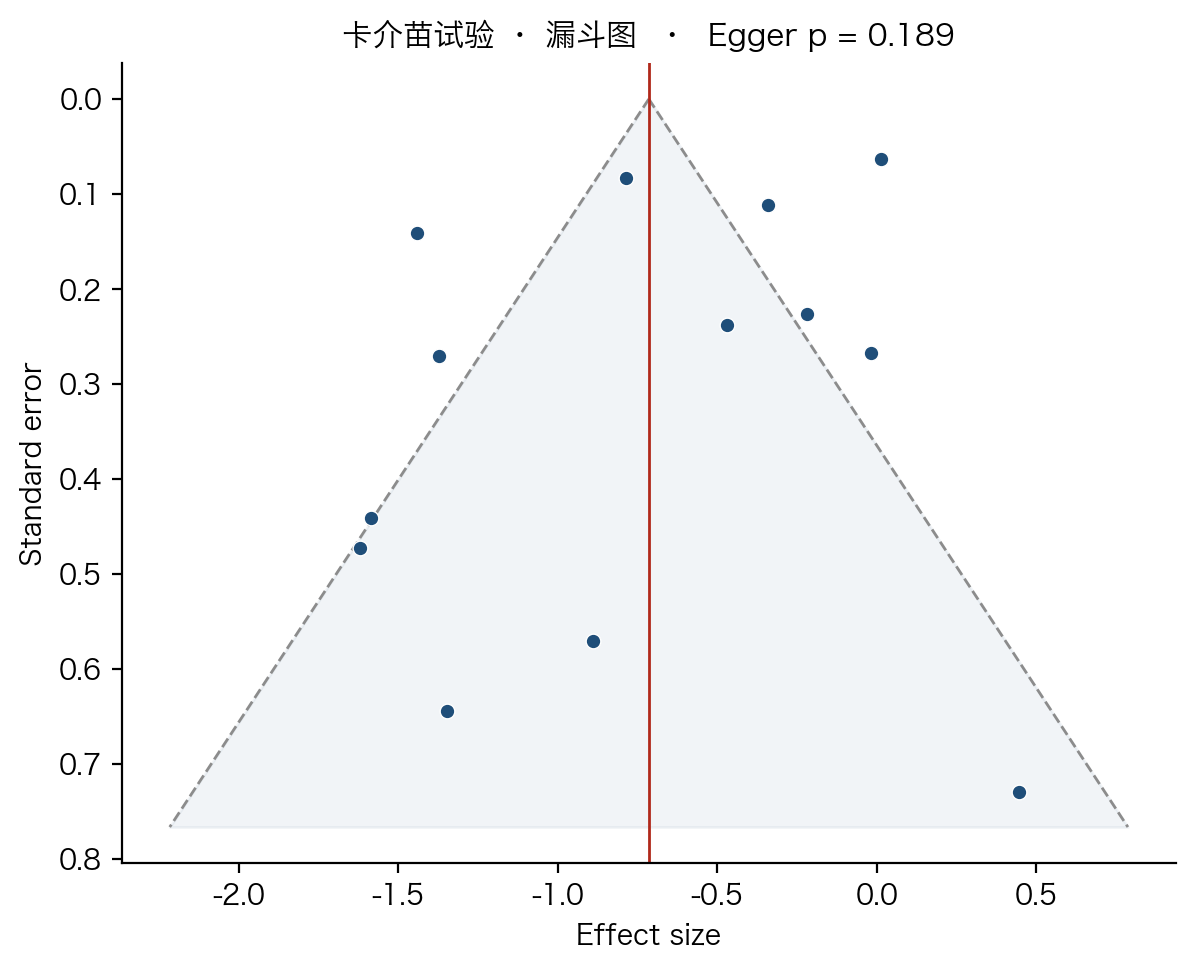

In [8]:
sv.tl.egger_test(study)
eg = study.diagnostics["egger"]
print(f"Egger 截距 = {eg['intercept']:.3f}  (p = {eg['pval']:.3f})")
print("p > 0.05:没有强证据表明存在小研究效应/发表偏倚(但研究数少时功效有限,别据此下定论)。")

sv.pl.funnel(study, out="fig22_funnel.png", title="卡介苗试验 · 漏斗图")
Image("fig22_funnel.png")

## 8. Forest Plot: Draw All Evidence into One Figure

A forest plot is the standard output of meta-analysis: one row per study, the square is the point estimate (size ∝ weight), horizontal line is the 95% CI; the red diamond at the bottom is the pooled estimate; below it is a line for the prediction interval. One figure simultaneously shows "what each study says," "what pooling says," and "how large is the heterogeneity."

/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/pl/_figure.py:136: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  fig.savefig(path, dpi=_DPI, bbox_inches="tight")


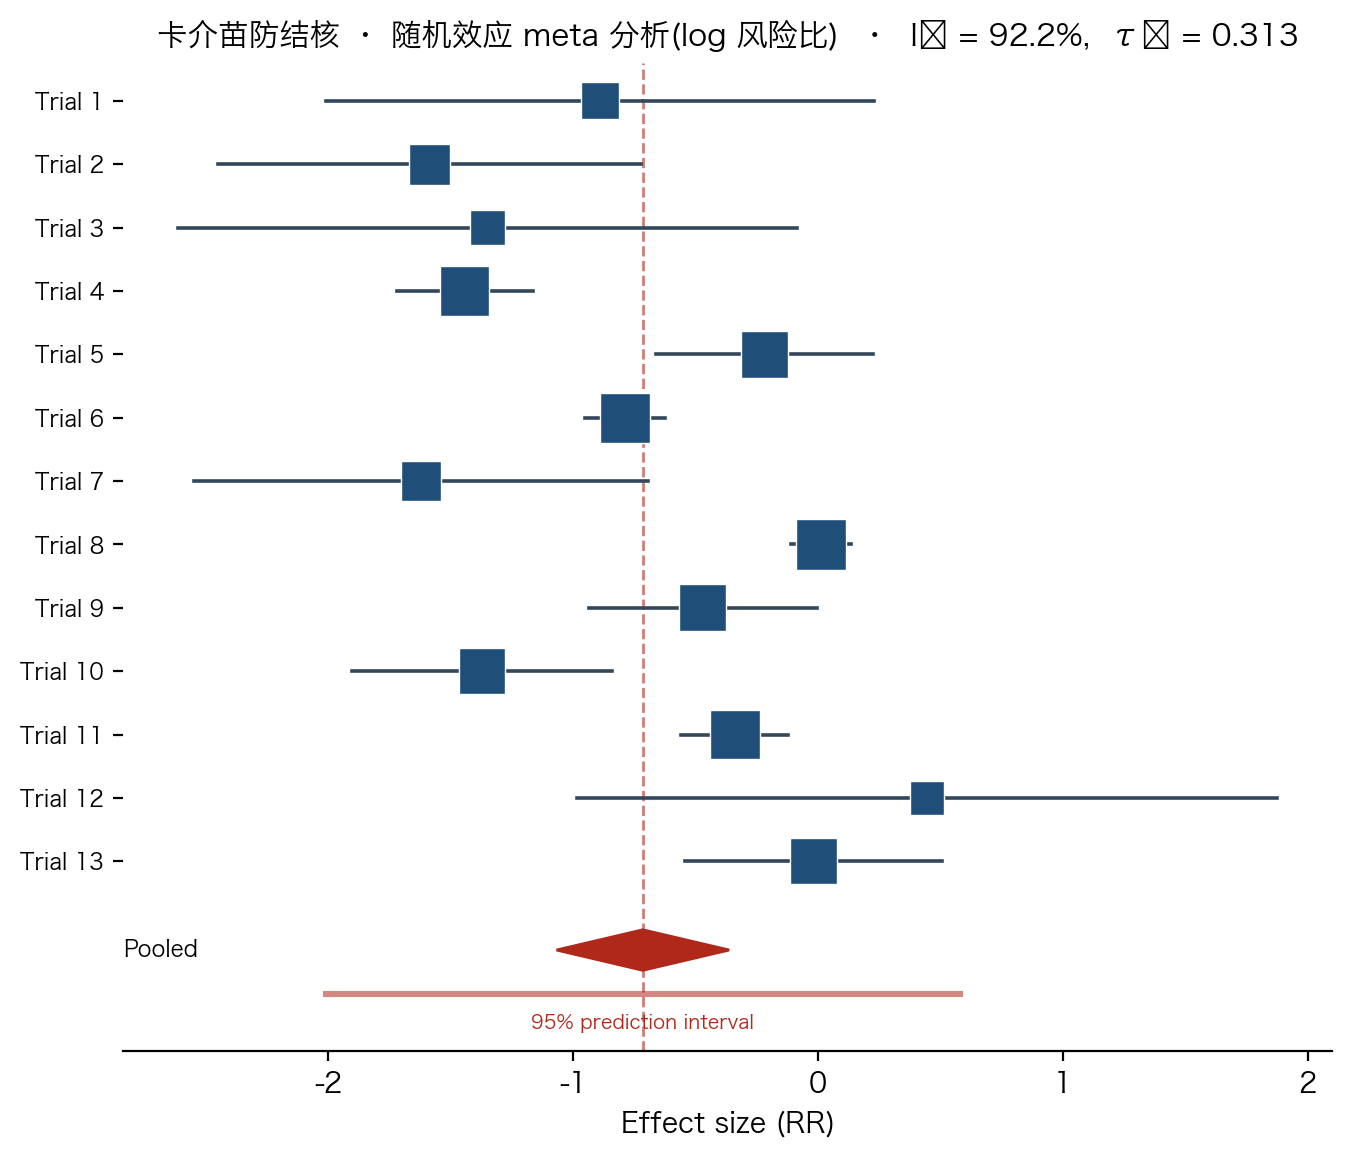

In [9]:
sv.pl.meta_forest(study, out="fig22_forest.png",
                  title="卡介苗防结核 · 随机效应 meta 分析(log 风险比)")
Image("fig22_forest.png")

## Summary: A Reproducible Evidence Chain

We walked through a standard meta-analysis with real data, each step sitting on a `StudyState` and every number traceable to which `sv.*` function it came from and which data it was computed from:

```
2×2 table ──sv.pp.escalc(RR)──▶ effect sizes (yi, vi)
        ──sv.tl.meta_random(REML, HKSJ)──▶ pooled log-RR = -0.7145 (byte-for-byte match with metafor)
        ──sv.tl.meta_heterogeneity──▶ I² = 92% (high heterogeneity)
        ──sv.tl.meta_prediction_interval──▶ prediction interval very wide
        ──sv.tl.egger_test / sv.pl.funnel──▶ no obvious publication bias
        ──sv.pl.meta_forest──▶ one figure collects all evidence
```

**Key points**: pooled point estimate always reported with I², prediction interval; when heterogeneity is high, frame conclusions using prediction interval language; enable Knapp-Hartung for small samples. Next notebook ([23 · Multilevel and Robust Meta](23_multilevel_and_robust_meta.ipynb)) handles a more thorny case: **each study contributes multiple dependent effect sizes**, where two-level random effects underestimates uncertainty, requiring three-level `rma_mv` and cluster-robust variance.